In [1]:
# ============================================================
# STATISTICAL COMPUTATION SCRIPT FOR CHECKERBOARD ASSAY RESULTS
# Prepared for statistical rerun in Jupyter Notebook / JupyterLab
# Prepared by: Engr. Jamie Eduardo Rosal, MSCpE
# ============================================================

# If needed, install required packages first:
# !pip install pandas numpy scipy statsmodels matplotlib openpyxl

from pathlib import Path
import re
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
# ============================================================
# 1. SET FILE PATH AND OUTPUT FOLDER
# ============================================================

DATA_PATH = Path("Results.xlsx")   # Change this if your file name/path is different

OUTPUT_DIR = Path("statistical_outputs")
FIG_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

print("Data file:", DATA_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Data file: /Users/freshliannes.rosal/Documents/Stat Client/Mary Project/Results.xlsx
Output folder: /Users/freshliannes.rosal/Documents/Stat Client/Mary Project/statistical_outputs


In [3]:
# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def clean_token(x):
    """
    Cleans text values from Excel cells.
    """
    if pd.isna(x):
        return np.nan
    return str(x).strip().replace("\t", "").strip()


def parse_concentration(x):
    """
    Extracts numeric concentration and unit from values such as:
    '15 ug/mL', '0.375 mg/mL', '1.5 mg/mL'
    """
    s = clean_token(x)
    if pd.isna(s):
        return np.nan, None

    m = re.search(r"([0-9]*\.?[0-9]+)\s*(ug|µg|mcg|mg)\s*/\s*mL", s, flags=re.I)

    if not m:
        return np.nan, None

    value = float(m.group(1))
    unit = m.group(2).lower().replace("µ", "u").replace("mcg", "ug") + "/mL"

    return value, unit


def classify_fici(x):
    """
    Classifies Sigma FIC using common checkerboard interpretation thresholds.
    """
    if pd.isna(x):
        return np.nan

    if x <= 0.5:
        return "Synergistic"
    elif x <= 1.0:
        return "Additive"
    elif x <= 4.0:
        return "Indifferent"
    else:
        return "Antagonistic"


def holm_adjust(pvalues):
    """
    Holm-Bonferroni correction for multiple pairwise tests.
    """
    pvalues = np.asarray([1 if pd.isna(p) else p for p in pvalues], dtype=float)
    m = len(pvalues)

    order = np.argsort(pvalues)
    adjusted = np.empty(m, dtype=float)

    previous = 0.0

    for rank, idx in enumerate(order):
        value = (m - rank) * pvalues[idx]
        value = max(value, previous)
        previous = value
        adjusted[idx] = min(value, 1.0)

    return adjusted

In [4]:
# ============================================================
# 3. PARSE THE EXCEL WORKBOOK
# ============================================================

def parse_workbook(path):
    """
    This parser is designed for the current Results.xlsx layout:
    - Erythromycin-alone MIC appears around row 8
    - Carbon-dots-alone MIC appears around row 17
    - Three checkerboard assay sets appear in blocks
    """

    raw = pd.read_excel(path, sheet_name="Sheet1", header=None)

    # Extract erythromycin-alone MIC values
    ery_mic_values = []
    for c in [1, 2, 3]:
        value, unit = parse_concentration(raw.iloc[7, c])
        ery_mic_values.append(value)

    # Extract carbon-dots-alone MIC values
    cd_mic_values = []
    for c in [1, 2, 3]:
        value, unit = parse_concentration(raw.iloc[16, c])
        cd_mic_values.append(value)

    ery_mic_alone = float(np.nanmean(ery_mic_values))
    cd_mic_alone = float(np.nanmean(cd_mic_values))

    response_records = []
    fic_records = []

    # Checkerboard assay block locations in the current workbook
    checkerboard_blocks = [
        (1, 18),
        (2, 28),
        (3, 38)
    ]

    for set_number, start_row in checkerboard_blocks:

        # Erythromycin concentrations across columns
        ery_columns = []
        for col in range(2, 7):
            ery_value, ery_unit = parse_concentration(raw.iloc[start_row + 1, col])
            ery_columns.append((col, ery_value, ery_unit))

        # Response matrix: turbid/clear response
        for row in range(start_row + 2, start_row + 7):
            cd_value, cd_unit = parse_concentration(raw.iloc[row, 1])

            for col, ery_value, ery_unit in ery_columns:
                response_records.append({
                    "set": set_number,
                    "carbon_dots_conc_mg_ml": cd_value,
                    "erythromycin_conc_ug_ml": ery_value,
                    "response": clean_token(raw.iloc[row, col])
                })

        # MIC in combination and FIC values
        for col, ery_value, ery_unit in ery_columns:
            cd_combo_mic, cd_combo_unit = parse_concentration(raw.iloc[start_row + 7, col])
            reported_fic = raw.iloc[start_row + 8, col]
            reported_interpretation = clean_token(raw.iloc[start_row + 9, col])

            fic_e = ery_value / ery_mic_alone
            fic_cd = cd_combo_mic / cd_mic_alone
            computed_fic = fic_e + fic_cd

            fic_records.append({
                "set": set_number,
                "erythromycin_mic_combination_ug_ml": ery_value,
                "carbon_dots_mic_combination_mg_ml": cd_combo_mic,
                "erythromycin_mic_alone_ug_ml": ery_mic_alone,
                "carbon_dots_mic_alone_mg_ml": cd_mic_alone,
                "fic_erythromycin": fic_e,
                "fic_carbon_dots": fic_cd,
                "reported_fic_index": float(reported_fic),
                "computed_fic_index": computed_fic,
                "reported_interpretation": reported_interpretation,
                "computed_interpretation": classify_fici(computed_fic),
                "fic_difference_reported_minus_computed": float(reported_fic) - computed_fic
            })

    response_df = pd.DataFrame(response_records)
    fic_df = pd.DataFrame(fic_records)

    return raw, response_df, fic_df


raw, response_df, fic_df = parse_workbook(DATA_PATH)

print("Checkerboard response dataset:")
display(response_df.head())

print("FIC dataset:")
display(fic_df)

Checkerboard response dataset:


,set,carbon_dots_conc_mg_ml,erythromycin_conc_ug_ml,response
0,1,3.0,15.0000,T
1,1,3.0,7.5000,T
2,1,3.0,3.7500,T
3,1,3.0,1.8750,T
4,1,3.0,0.9375,T


FIC dataset:


,set,erythromycin_mic_combination_ug_ml,carbon_dots_mic_combination_mg_ml,erythromycin_mic_alone_ug_ml,carbon_dots_mic_alone_mg_ml,fic_erythromycin,fic_carbon_dots,reported_fic_index,computed_fic_index,reported_interpretation,computed_interpretation,fic_difference_reported_minus_computed
0,1,15.0000,0.3750,15.0,0.375,1.0000,1.0,2.0000,2.0000,Indifferent,Indifferent,0.0000
1,1,7.5000,0.3750,15.0,0.375,0.5000,1.0,1.5000,1.5000,Indifferent,Indifferent,0.0000
2,1,3.7500,0.7500,15.0,0.375,0.2500,2.0,2.2500,2.2500,Indifferent,Indifferent,0.0000
3,1,1.8750,0.7500,15.0,0.375,0.1250,2.0,2.1250,2.1250,Indifferent,Indifferent,0.0000
4,1,0.9375,0.1875,15.0,0.375,0.0625,0.5,0.5625,0.5625,Indifferent,Additive,0.0000
5,2,15.0000,0.7500,15.0,0.375,1.0000,2.0,3.0000,3.0000,Indifferent,Indifferent,0.0000
6,2,7.5000,0.7500,15.0,0.375,0.5000,2.0,2.5000,2.5000,Indifferent,Indifferent,0.0000
7,2,3.7500,0.7500,15.0,0.375,0.2500,2.0,2.2500,2.2500,Indifferent,Indifferent,0.0000
8,2,1.8750,0.3750,15.0,0.375,0.1250,1.0,1.1250,1.1250,Indifferent,Indifferent,0.0000
9,2,0.9375,0.7500,15.0,0.375,0.0625,2.0,2.0650,2.0625,Indifferent,Indifferent,0.0025


In [5]:
# ============================================================
# 4. MIC REFERENCES
# ============================================================

ery_mic = fic_df["erythromycin_mic_alone_ug_ml"].iloc[0]
cd_mic = fic_df["carbon_dots_mic_alone_mg_ml"].iloc[0]

print("MIC References Used")
print(f"Erythromycin-alone MIC: {ery_mic:.4g} ug/mL")
print(f"Carbon-dots-alone MIC: {cd_mic:.4g} mg/mL")

MIC References Used
Erythromycin-alone MIC: 15 ug/mL
Carbon-dots-alone MIC: 0.375 mg/mL


In [6]:
# ============================================================
# 5. DESCRIPTIVE STATISTICS OF SIGMA FIC
# ============================================================

summary = (
    fic_df.groupby("erythromycin_mic_combination_ug_ml")
    .agg(
        n=("computed_fic_index", "count"),
        mean_fic=("computed_fic_index", "mean"),
        median_fic=("computed_fic_index", "median"),
        sd_fic=("computed_fic_index", "std"),
        min_fic=("computed_fic_index", "min"),
        max_fic=("computed_fic_index", "max")
    )
    .reset_index()
    .sort_values("erythromycin_mic_combination_ug_ml", ascending=False)
)

summary["sem"] = summary["sd_fic"] / np.sqrt(summary["n"])

summary["ci95_low"] = (
    summary["mean_fic"]
    - stats.t.ppf(0.975, summary["n"] - 1) * summary["sem"]
)

summary["ci95_high"] = (
    summary["mean_fic"]
    + stats.t.ppf(0.975, summary["n"] - 1) * summary["sem"]
)

# If SD is zero, CI is the mean itself
mask_zero_sd = summary["sd_fic"].fillna(0) == 0
summary.loc[mask_zero_sd, "ci95_low"] = summary.loc[mask_zero_sd, "mean_fic"]
summary.loc[mask_zero_sd, "ci95_high"] = summary.loc[mask_zero_sd, "mean_fic"]

display(summary)

,erythromycin_mic_combination_ug_ml,n,mean_fic,median_fic,sd_fic,min_fic,max_fic,sem,ci95_low,ci95_high
4,15.0000,3,2.666667,3.0000,0.577350,2.0000,3.0000,0.333333,1.232449,4.100884
3,7.5000,3,1.833333,1.5000,0.577350,1.5000,2.5000,0.333333,0.399116,3.267551
2,3.7500,3,2.250000,2.2500,0.000000,2.2500,2.2500,0.000000,2.250000,2.250000
1,1.8750,3,1.458333,1.1250,0.577350,1.1250,2.1250,0.333333,0.024116,2.892551
0,0.9375,3,1.062500,0.5625,0.866025,0.5625,2.0625,0.500000,-1.088826,3.213826


In [7]:
# ============================================================
# 6. RESPONSE FREQUENCY AND FIC INTERPRETATION FREQUENCY
# ============================================================

response_counts = (
    response_df["response"]
    .value_counts(dropna=False)
    .rename_axis("response")
    .reset_index(name="count")
)

response_counts["percentage"] = (
    response_counts["count"] / response_counts["count"].sum() * 100
)

interpretation_counts = (
    fic_df["computed_interpretation"]
    .value_counts()
    .rename_axis("computed_interpretation")
    .reset_index(name="count")
)

interpretation_counts["percentage"] = (
    interpretation_counts["count"] / interpretation_counts["count"].sum() * 100
)

print("Checkerboard response counts:")
display(response_counts)

print("Computed FIC interpretation counts:")
display(interpretation_counts)

Checkerboard response counts:


,response,count,percentage
0,T,39,52.0
1,SC,36,48.0


Computed FIC interpretation counts:


,computed_interpretation,count,percentage
0,Indifferent,13,86.666667
1,Additive,2,13.333333


In [8]:
# ============================================================
# 7. CHECK REPORTED VS COMPUTED FIC INTERPRETATION
# ============================================================

mismatches = fic_df.loc[
    fic_df["reported_interpretation"] != fic_df["computed_interpretation"],
    [
        "set",
        "erythromycin_mic_combination_ug_ml",
        "reported_fic_index",
        "computed_fic_index",
        "reported_interpretation",
        "computed_interpretation"
    ]
]

print(f"Number of interpretation mismatches: {len(mismatches)}")
display(mismatches)

Number of interpretation mismatches: 1


,set,erythromycin_mic_combination_ug_ml,reported_fic_index,computed_fic_index,reported_interpretation,computed_interpretation
4,1,0.9375,0.5625,0.5625,Indifferent,Additive


In [9]:
# ============================================================
# 8. ASSUMPTION CHECKING
# ============================================================

normality_rows = []

for conc, group in fic_df.groupby("erythromycin_mic_combination_ug_ml"):

    if len(group) >= 3 and group["computed_fic_index"].nunique() > 1:
        shapiro_stat, shapiro_p = stats.shapiro(group["computed_fic_index"])
        note = "Computed, but unstable because n = 3."
    else:
        shapiro_stat, shapiro_p = np.nan, np.nan
        note = "Not reliable or not computable because n is too small or values are constant."

    normality_rows.append({
        "erythromycin_mic_combination_ug_ml": conc,
        "n": len(group),
        "shapiro_w": shapiro_stat,
        "p_value": shapiro_p,
        "note": note
    })

normality_df = pd.DataFrame(normality_rows).sort_values(
    "erythromycin_mic_combination_ug_ml",
    ascending=False
)

display(normality_df)

,erythromycin_mic_combination_ug_ml,n,shapiro_w,p_value,note
4,15.0000,3,0.75,7.420804e-16,"Computed, but unstable because n = 3."
3,7.5000,3,0.75,1.059695e-16,"Computed, but unstable because n = 3."
2,3.7500,3,NaN,NaN,Not reliable or not computable because n is to...
1,1.8750,3,0.75,0.000000e+00,"Computed, but unstable because n = 3."
0,0.9375,3,0.75,1.059695e-16,"Computed, but unstable because n = 3."


In [10]:
# ============================================================
# 9. REPEATED-MEASURES DATA STRUCTURE
# ============================================================

ordered_cols = sorted(
    fic_df["erythromycin_mic_combination_ug_ml"].unique(),
    reverse=True
)

pivot = fic_df.pivot(
    index="set",
    columns="erythromycin_mic_combination_ug_ml",
    values="computed_fic_index"
)

pivot = pivot[ordered_cols]

print("Repeated-measures FIC matrix:")
display(pivot)

Repeated-measures FIC matrix:


erythromycin_mic_combination_ug_ml,15.0000,7.5000,3.7500,1.8750,0.9375
set,,,,,
1,2.0,1.5,2.25,2.125,0.5625
2,3.0,2.5,2.25,1.125,2.0625
3,3.0,1.5,2.25,1.125,0.5625


In [11]:
# ============================================================
# 10. EXPLORATORY NON-PARAMETRIC TEST: FRIEDMAN TEST
# ============================================================

friedman_result = stats.friedmanchisquare(
    *[pivot[c] for c in ordered_cols]
)

kendalls_w = (
    friedman_result.statistic
    / (pivot.shape[0] * (pivot.shape[1] - 1))
)

print("Friedman repeated-measures test")
print(f"Chi-square = {friedman_result.statistic:.4f}")
print(f"p-value = {friedman_result.pvalue:.4f}")
print(f"Kendall's W = {kendalls_w:.4f}")

Friedman repeated-measures test
Chi-square = 7.2000
p-value = 0.1257
Kendall's W = 0.6000


In [12]:
# ============================================================
# 11. EXPLORATORY SPEARMAN CORRELATION
# ============================================================

spearman_result = stats.spearmanr(
    fic_df["erythromycin_mic_combination_ug_ml"],
    fic_df["computed_fic_index"]
)

print("Spearman correlation between erythromycin concentration and Sigma FIC")
print(f"rho = {spearman_result.statistic:.4f}")
print(f"p-value = {spearman_result.pvalue:.4f}")

Spearman correlation between erythromycin concentration and Sigma FIC
rho = 0.6374
p-value = 0.0106


In [13]:
# ============================================================
# 12. OBJECTIVE 7: ANOVA, t-TEST, AND POST HOC ANALYSES
# ============================================================

# 12A. One-way ANOVA
# This treats groups as independent.
# It is included for manuscript alignment but is not the best test
# because the same assay sets are repeated across concentrations.

groups = [
    fic_df.loc[
        fic_df["erythromycin_mic_combination_ug_ml"] == c,
        "computed_fic_index"
    ].values
    for c in ordered_cols
]

oneway_f, oneway_p = stats.f_oneway(*groups)

print("One-way ANOVA across erythromycin concentrations")
print(f"F = {oneway_f:.4f}")
print(f"p-value = {oneway_p:.4f}")

One-way ANOVA across erythromycin concentrations
F = 3.4301
p-value = 0.0518


In [14]:
# ============================================================
# 13. OBJECTIVE 7: REPEATED-MEASURES ANOVA
# ============================================================

# This is more appropriate than one-way ANOVA because the same assay sets
# were measured across erythromycin concentration levels.

rm_anova_result = AnovaRM(
    fic_df.copy(),
    depvar="computed_fic_index",
    subject="set",
    within=["erythromycin_mic_combination_ug_ml"]
).fit()

rm_table = rm_anova_result.anova_table.reset_index().rename(
    columns={"index": "source"}
)

display(rm_table)

rm_f = float(rm_table.loc[0, "F Value"])
rm_p = float(rm_table.loc[0, "Pr > F"])
rm_numdf = float(rm_table.loc[0, "Num DF"])
rm_dendf = float(rm_table.loc[0, "Den DF"])

partial_eta_sq = (rm_f * rm_numdf) / ((rm_f * rm_numdf) + rm_dendf)

print("Repeated-measures ANOVA")
print(f"F({rm_numdf:.0f}, {rm_dendf:.0f}) = {rm_f:.4f}")
print(f"p-value = {rm_p:.4f}")
print(f"Partial eta squared = {partial_eta_sq:.4f}")

,source,F Value,Num DF,Den DF,Pr > F
0,erythromycin_mic_combination_ug_ml,3.601563,4.0,8.0,0.058046


Repeated-measures ANOVA
F(4, 8) = 3.6016
p-value = 0.0580
Partial eta squared = 0.6430


In [15]:
# ============================================================
# 14. OBJECTIVE 7: PAIRED t-TEST POST HOC WITH HOLM CORRECTION
# ============================================================

paired_rows = []

for a, b in itertools.combinations(ordered_cols, 2):

    x = pivot[a].to_numpy()
    y = pivot[b].to_numpy()
    diff = x - y

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        t_res = stats.ttest_rel(x, y)

    sd_diff = np.std(diff, ddof=1)

    if sd_diff > 0:
        cohen_dz = np.mean(diff) / sd_diff
    else:
        cohen_dz = np.nan

    paired_rows.append({
        "comparison": f"{a:g} vs {b:g} ug/mL",
        "mean_a": np.mean(x),
        "mean_b": np.mean(y),
        "mean_difference": np.mean(diff),
        "t_stat": t_res.statistic,
        "df": len(x) - 1,
        "p_uncorrected": t_res.pvalue,
        "cohen_dz": cohen_dz
    })

paired_t_df = pd.DataFrame(paired_rows)

paired_t_df["p_holm"] = holm_adjust(paired_t_df["p_uncorrected"])

paired_t_df["decision_alpha_0_05"] = np.where(
    paired_t_df["p_holm"] < 0.05,
    "Significant",
    "Not significant"
)

display(paired_t_df.sort_values("p_holm"))

,comparison,mean_a,mean_b,mean_difference,t_stat,df,p_uncorrected,cohen_dz,p_holm,decision_alpha_0_05
6,7.5 vs 0.9375 ug/mL,1.833333,1.062500,0.770833,4.625000,2,0.043707,2.670245,0.437073,Not significant
3,15 vs 0.9375 ug/mL,2.666667,1.062500,1.604167,3.637908,2,0.067950,2.100347,0.611546,Not significant
0,15 vs 7.5 ug/mL,2.666667,1.833333,0.833333,2.500000,2,0.129612,1.443376,1.000000,Not significant
1,15 vs 3.75 ug/mL,2.666667,2.250000,0.416667,1.250000,2,0.337734,0.721688,1.000000,Not significant
2,15 vs 1.875 ug/mL,2.666667,1.458333,1.208333,1.812500,2,0.211595,1.046447,1.000000,Not significant
4,7.5 vs 3.75 ug/mL,1.833333,2.250000,-0.416667,-1.250000,2,0.337734,-0.721688,1.000000,Not significant
5,7.5 vs 1.875 ug/mL,1.833333,1.458333,0.375000,0.649519,2,0.582635,0.375000,1.000000,Not significant
7,3.75 vs 1.875 ug/mL,2.250000,1.458333,0.791667,2.375000,2,0.140790,1.371207,1.000000,Not significant
8,3.75 vs 0.9375 ug/mL,2.250000,1.062500,1.187500,2.375000,2,0.140790,1.371207,1.000000,Not significant
9,1.875 vs 0.9375 ug/mL,1.458333,1.062500,0.395833,0.544862,2,0.640484,0.314576,1.000000,Not significant


In [16]:
# ============================================================
# 15. OBJECTIVE 7: WELCH INDEPENDENT t-TEST POST HOC
# ============================================================

# This is supplementary only because the actual design is repeated by assay set.
# It is useful if your panel expects independent t-test output.

welch_rows = []

for a, b in itertools.combinations(ordered_cols, 2):

    x = fic_df.loc[
        fic_df["erythromycin_mic_combination_ug_ml"] == a,
        "computed_fic_index"
    ].to_numpy()

    y = fic_df.loc[
        fic_df["erythromycin_mic_combination_ug_ml"] == b,
        "computed_fic_index"
    ].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        res = stats.ttest_ind(x, y, equal_var=False)

    sx = np.var(x, ddof=1)
    sy = np.var(y, ddof=1)
    nx = len(x)
    ny = len(y)

    if sx == 0 and sy == 0:
        welch_df = np.nan
    else:
        welch_df = ((sx / nx + sy / ny) ** 2) / (
            ((sx / nx) ** 2) / (nx - 1)
            + ((sy / ny) ** 2) / (ny - 1)
        )

    pooled_sd = np.sqrt(
        ((nx - 1) * sx + (ny - 1) * sy)
        / (nx + ny - 2)
    )

    if pooled_sd > 0:
        cohen_d = (np.mean(x) - np.mean(y)) / pooled_sd
    else:
        cohen_d = np.nan

    welch_rows.append({
        "comparison": f"{a:g} vs {b:g} ug/mL",
        "mean_a": np.mean(x),
        "mean_b": np.mean(y),
        "mean_difference": np.mean(x) - np.mean(y),
        "t_stat": res.statistic,
        "df": welch_df,
        "p_uncorrected": res.pvalue,
        "cohen_d": cohen_d
    })

welch_t_df = pd.DataFrame(welch_rows)

welch_t_df["p_holm"] = holm_adjust(welch_t_df["p_uncorrected"])

welch_t_df["decision_alpha_0_05"] = np.where(
    welch_t_df["p_holm"] < 0.05,
    "Significant",
    "Not significant"
)

display(welch_t_df.sort_values("p_holm"))

,comparison,mean_a,mean_b,mean_difference,t_stat,df,p_uncorrected,cohen_d,p_holm,decision_alpha_0_05
2,15 vs 1.875 ug/mL,2.666667,1.458333,1.208333,2.563262,4.000000,0.062422,2.092895,0.624221,Not significant
3,15 vs 0.9375 ug/mL,2.666667,1.062500,1.604167,2.669495,3.484536,0.064572,2.179633,0.624221,Not significant
0,15 vs 7.5 ug/mL,2.666667,1.833333,0.833333,1.767767,4.000000,0.151835,1.443376,1.000000,Not significant
1,15 vs 3.75 ug/mL,2.666667,2.250000,0.416667,1.250000,2.000000,0.337734,1.020621,1.000000,Not significant
4,7.5 vs 3.75 ug/mL,1.833333,2.250000,-0.416667,-1.250000,2.000000,0.337734,-1.020621,1.000000,Not significant
5,7.5 vs 1.875 ug/mL,1.833333,1.458333,0.375000,0.795495,4.000000,0.470863,0.649519,1.000000,Not significant
6,7.5 vs 0.9375 ug/mL,1.833333,1.062500,0.770833,1.282744,3.484536,0.278253,1.047356,1.000000,Not significant
7,3.75 vs 1.875 ug/mL,2.250000,1.458333,0.791667,2.375000,2.000000,0.140790,1.939179,1.000000,Not significant
8,3.75 vs 0.9375 ug/mL,2.250000,1.062500,1.187500,2.375000,2.000000,0.140790,1.939179,1.000000,Not significant
9,1.875 vs 0.9375 ug/mL,1.458333,1.062500,0.395833,0.658706,3.484536,0.551038,0.537832,1.000000,Not significant


In [17]:
# ============================================================
# 16. OBJECTIVE 7: TUKEY HSD POST HOC
# ============================================================

# Tukey HSD is included for manuscript alignment.
# Important: Tukey HSD assumes independent groups.
# In this dataset, results are repeated by assay set, so interpret as exploratory only.

tukey = pairwise_tukeyhsd(
    endog=fic_df["computed_fic_index"],
    groups=fic_df["erythromycin_mic_combination_ug_ml"].astype(str),
    alpha=0.05
)

print(tukey)

tukey_df = pd.DataFrame(
    tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)

for col in ["meandiff", "p-adj", "lower", "upper"]:
    tukey_df[col] = pd.to_numeric(tukey_df[col], errors="coerce")

display(tukey_df)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
0.9375  1.875   0.3958 0.9187 -1.1939 1.9856  False
0.9375   15.0   1.6042 0.0477  0.0144 3.1939   True
0.9375   3.75   1.1875 0.1768 -0.4022 2.7772  False
0.9375    7.5   0.7708 0.5312 -0.8189 2.3606  False
 1.875   15.0   1.2083 0.1661 -0.3814 2.7981  False
 1.875   3.75   0.7917 0.5077 -0.7981 2.3814  False
 1.875    7.5    0.375 0.9318 -1.2147 1.9647  False
  15.0   3.75  -0.4167 0.9042 -2.0064 1.1731  False
  15.0    7.5  -0.8333 0.4619 -2.4231 0.7564  False
  3.75    7.5  -0.4167 0.9042 -2.0064 1.1731  False
---------------------------------------------------


,group1,group2,meandiff,p-adj,lower,upper,reject
0,0.9375,1.875,0.3958,0.9187,-1.1939,1.9856,False
1,0.9375,15.0,1.6042,0.0477,0.0144,3.1939,True
2,0.9375,3.75,1.1875,0.1768,-0.4022,2.7772,False
3,0.9375,7.5,0.7708,0.5312,-0.8189,2.3606,False
4,1.875,15.0,1.2083,0.1661,-0.3814,2.7981,False
5,1.875,3.75,0.7917,0.5077,-0.7981,2.3814,False
6,1.875,7.5,0.3750,0.9318,-1.2147,1.9647,False
7,15.0,3.75,-0.4167,0.9042,-2.0064,1.1731,False
8,15.0,7.5,-0.8333,0.4619,-2.4231,0.7564,False
9,3.75,7.5,-0.4167,0.9042,-2.0064,1.1731,False


In [18]:
# ============================================================
# 17. OBJECTIVE 7: SUMMARY TABLE OF OMNIBUS TESTS
# ============================================================

anova_summary_df = pd.DataFrame([
    {
        "analysis": "One-way ANOVA across erythromycin concentrations",
        "statistic": f"F = {oneway_f:.4f}",
        "df": "4, 10",
        "p_value": oneway_p,
        "effect_size": "Not primary; repeated design ignored",
        "interpretation": "Borderline but not significant at alpha = 0.05."
    },
    {
        "analysis": "Repeated-measures ANOVA across erythromycin concentrations",
        "statistic": f"F = {rm_f:.4f}",
        "df": f"{rm_numdf:.0f}, {rm_dendf:.0f}",
        "p_value": rm_p,
        "effect_size": f"partial eta squared = {partial_eta_sq:.4f}",
        "interpretation": "Borderline but not significant at alpha = 0.05; more appropriate than one-way ANOVA."
    },
    {
        "analysis": "Friedman repeated-measures test",
        "statistic": f"chi-square = {friedman_result.statistic:.4f}",
        "df": "4",
        "p_value": friedman_result.pvalue,
        "effect_size": f"Kendall's W = {kendalls_w:.4f}",
        "interpretation": "Not significant; non-parametric support for cautious interpretation."
    }
])

display(anova_summary_df)

,analysis,statistic,df,p_value,effect_size,interpretation
0,One-way ANOVA across erythromycin concentrations,F = 3.4301,"4, 10",0.051831,Not primary; repeated design ignored,Borderline but not significant at alpha = 0.05.
1,Repeated-measures ANOVA across erythromycin co...,F = 3.6016,"4, 8",0.058046,partial eta squared = 0.6430,Borderline but not significant at alpha = 0.05...
2,Friedman repeated-measures test,chi-square = 7.2000,4,0.125689,Kendall's W = 0.6000,Not significant; non-parametric support for ca...


In [19]:
# ============================================================
# 18. ISOBOLGRAM-READY DATA
# ============================================================

# Each point uses:
# x-axis = FIC of erythromycin
# y-axis = FIC of carbon dots

isobologram_df = fic_df[
    [
        "set",
        "erythromycin_mic_combination_ug_ml",
        "carbon_dots_mic_combination_mg_ml",
        "fic_erythromycin",
        "fic_carbon_dots",
        "computed_fic_index",
        "computed_interpretation"
    ]
].copy()

display(isobologram_df)

,set,erythromycin_mic_combination_ug_ml,carbon_dots_mic_combination_mg_ml,fic_erythromycin,fic_carbon_dots,computed_fic_index,computed_interpretation
0,1,15.0000,0.3750,1.0000,1.0,2.0000,Indifferent
1,1,7.5000,0.3750,0.5000,1.0,1.5000,Indifferent
2,1,3.7500,0.7500,0.2500,2.0,2.2500,Indifferent
3,1,1.8750,0.7500,0.1250,2.0,2.1250,Indifferent
4,1,0.9375,0.1875,0.0625,0.5,0.5625,Additive
5,2,15.0000,0.7500,1.0000,2.0,3.0000,Indifferent
6,2,7.5000,0.7500,0.5000,2.0,2.5000,Indifferent
7,2,3.7500,0.7500,0.2500,2.0,2.2500,Indifferent
8,2,1.8750,0.3750,0.1250,1.0,1.1250,Indifferent
9,2,0.9375,0.7500,0.0625,2.0,2.0625,Indifferent


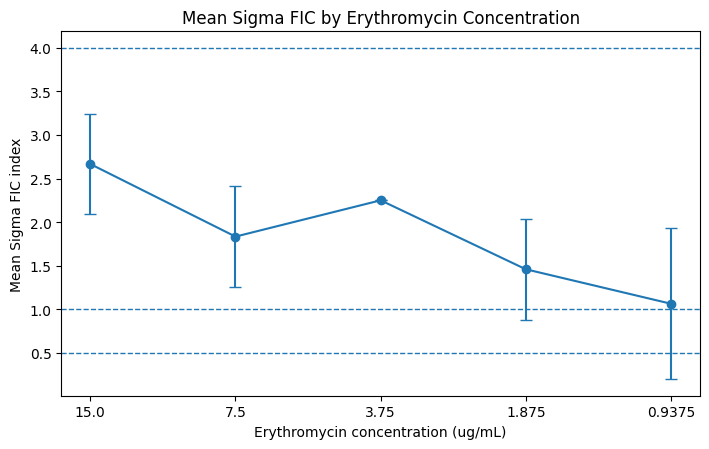

In [20]:
# ============================================================
# 19. FIGURE 1: MEAN SIGMA FIC BY ERYTHROMYCIN CONCENTRATION
# ============================================================

plt.figure(figsize=(7.2, 4.6))

x_labels = summary["erythromycin_mic_combination_ug_ml"].astype(str)

plt.errorbar(
    x_labels,
    summary["mean_fic"],
    yerr=summary["sd_fic"].fillna(0),
    marker="o",
    capsize=4
)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(4.0, linestyle="--", linewidth=1)

plt.xlabel("Erythromycin concentration (ug/mL)")
plt.ylabel("Mean Sigma FIC index")
plt.title("Mean Sigma FIC by Erythromycin Concentration")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig1_mean_fic_by_erythromycin.png", dpi=300)
plt.show()

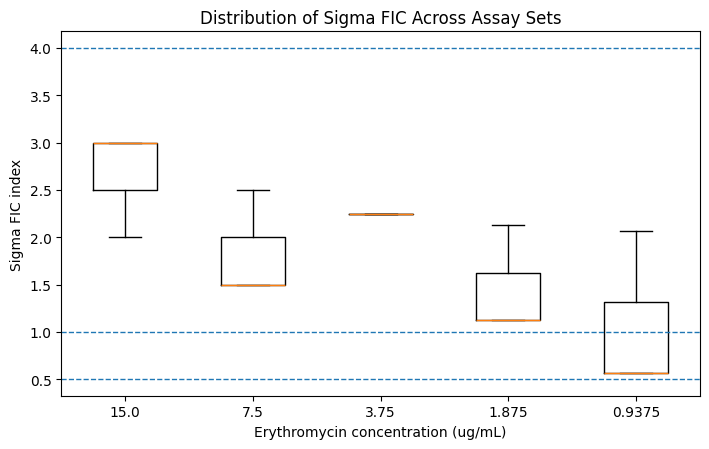

In [21]:
# ============================================================
# 20. FIGURE 2: BOXPLOT OF SIGMA FIC
# ============================================================

plt.figure(figsize=(7.2, 4.6))

box_groups = [
    fic_df.loc[
        fic_df["erythromycin_mic_combination_ug_ml"] == c,
        "computed_fic_index"
    ]
    for c in ordered_cols
]

plt.boxplot(
    box_groups,
    tick_labels=[str(c) for c in ordered_cols]
)

plt.axhline(0.5, linestyle="--", linewidth=1)
plt.axhline(1.0, linestyle="--", linewidth=1)
plt.axhline(4.0, linestyle="--", linewidth=1)

plt.xlabel("Erythromycin concentration (ug/mL)")
plt.ylabel("Sigma FIC index")
plt.title("Distribution of Sigma FIC Across Assay Sets")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig2_fic_boxplot_by_erythromycin.png", dpi=300)
plt.show()

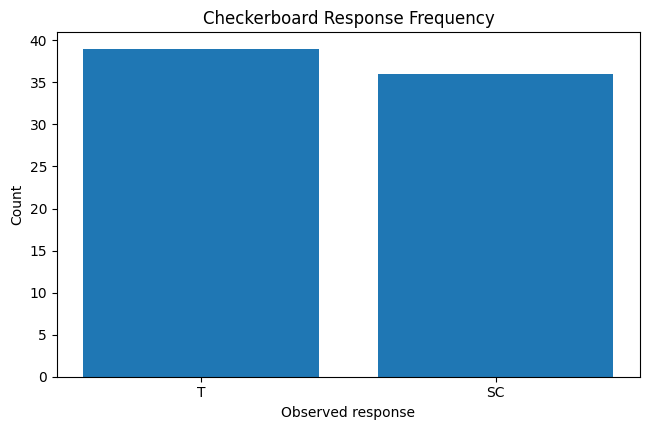

In [22]:
# ============================================================
# 21. FIGURE 3: CHECKERBOARD RESPONSE FREQUENCY
# ============================================================

plt.figure(figsize=(6.6, 4.4))

plt.bar(
    response_counts["response"].astype(str),
    response_counts["count"]
)

plt.xlabel("Observed response")
plt.ylabel("Count")
plt.title("Checkerboard Response Frequency")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig3_response_frequency.png", dpi=300)
plt.show()

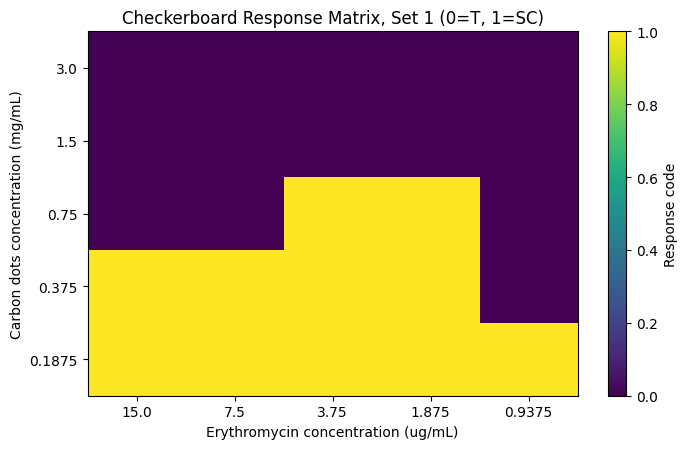

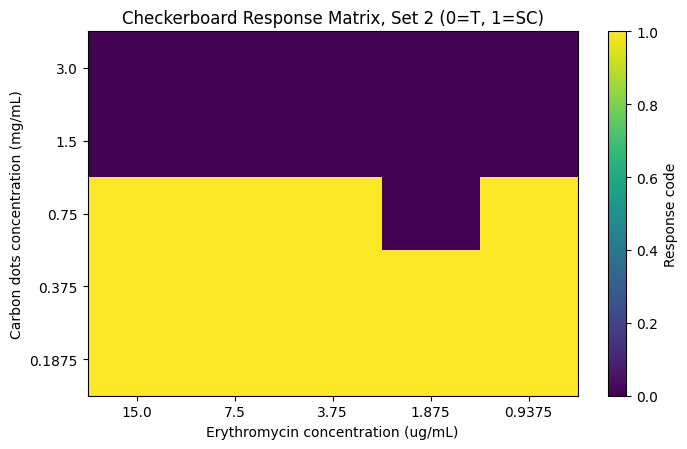

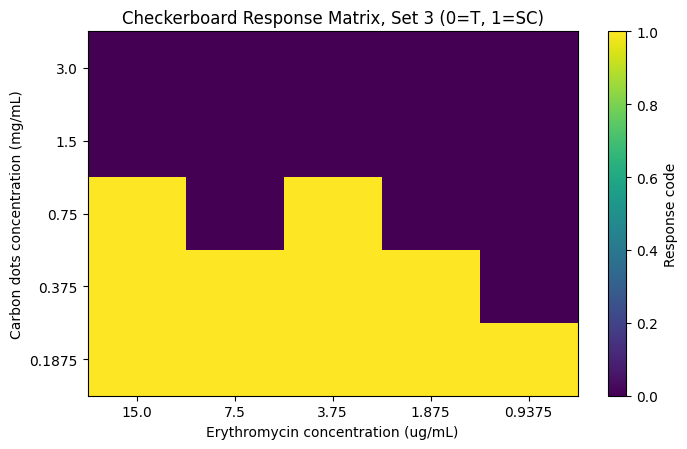

In [23]:
# ============================================================
# 22. FIGURE 4: CHECKERBOARD RESPONSE MATRICES
# ============================================================

for set_number in sorted(response_df["set"].unique()):

    mat = response_df[response_df["set"] == set_number].copy()

    matrix = mat.pivot(
        index="carbon_dots_conc_mg_ml",
        columns="erythromycin_conc_ug_ml",
        values="response"
    )

    matrix = matrix.sort_index(ascending=False)
    matrix = matrix.reindex(sorted(matrix.columns, reverse=True), axis=1)

    encoded = matrix.replace({"T": 0, "SC": 1}).astype(float)

    plt.figure(figsize=(7.2, 4.6))

    plt.imshow(encoded.values, aspect="auto")

    plt.xticks(
        range(encoded.shape[1]),
        [str(c) for c in encoded.columns]
    )

    plt.yticks(
        range(encoded.shape[0]),
        [str(i) for i in encoded.index]
    )

    plt.xlabel("Erythromycin concentration (ug/mL)")
    plt.ylabel("Carbon dots concentration (mg/mL)")
    plt.title(f"Checkerboard Response Matrix, Set {set_number} (0=T, 1=SC)")

    plt.colorbar(label="Response code")
    plt.tight_layout()

    plt.savefig(FIG_DIR / f"fig4_checkerboard_response_set_{set_number}.png", dpi=300)
    plt.show()

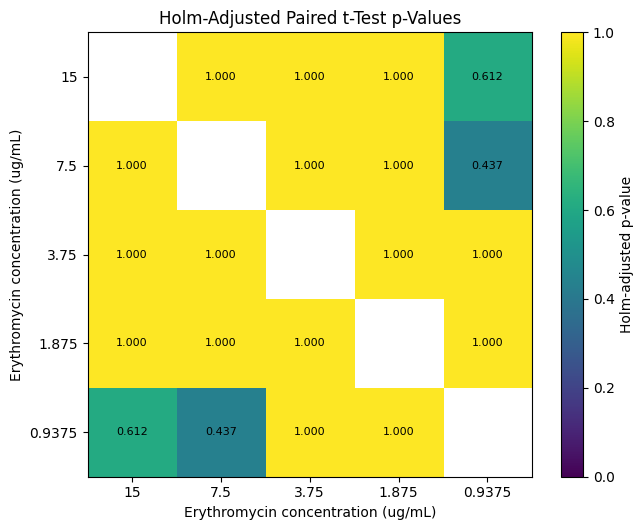

In [24]:
# ============================================================
# 23. FIGURE 5: OBJECTIVE 7 HOLM-ADJUSTED p-VALUE MATRIX
# ============================================================

labels = [f"{c:g}" for c in ordered_cols]

p_matrix = np.ones((len(ordered_cols), len(ordered_cols))) * np.nan

for _, row in paired_t_df.iterrows():

    c1, c2 = row["comparison"].split(" vs ")
    c1 = float(c1)
    c2 = float(c2.split()[0])

    i = ordered_cols.index(c1)
    j = ordered_cols.index(c2)

    p_matrix[i, j] = row["p_holm"]
    p_matrix[j, i] = row["p_holm"]

plt.figure(figsize=(6.8, 5.4))

im = plt.imshow(p_matrix, vmin=0, vmax=1)

plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)

plt.xlabel("Erythromycin concentration (ug/mL)")
plt.ylabel("Erythromycin concentration (ug/mL)")
plt.title("Holm-Adjusted Paired t-Test p-Values")

for i in range(len(labels)):
    for j in range(len(labels)):
        if not np.isnan(p_matrix[i, j]):
            plt.text(
                j,
                i,
                f"{p_matrix[i, j]:.3f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.colorbar(im, label="Holm-adjusted p-value")
plt.tight_layout()

plt.savefig(FIG_DIR / "fig5_posthoc_holm_pvalue_matrix.png", dpi=300)
plt.show()